<a href="https://colab.research.google.com/github/SANGHATI23/ohdsi-fhir-omop-showcase-demo/blob/main/FHIRy_pyOMOP_TFL_SubmissionFreezeRunner_v15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FHIRy–pyOMOP TFL Submission Freeze Runner

This notebook implements **P0.7: the submission-freeze runner**.

It does not add a new experiment. It integrates the finalized TFL evidence from v10–v14, replaces the older broad medication-attribution warning logic with the hardened v14 deterministic rule, preserves the unresolved-reference result as a focused micro-test outside V0–V5, recomputes the final primary metrics, and exports one manuscript-ready evidence package.

The runner is deliberately conservative:

- it first reproduces the locked v10/v11 metrics from the corrected audits;
- it stops if the metric definitions do not reproduce those values;
- it stops if the medication warning cannot be merged unambiguously;
- it never guesses a new information-fate category;
- it verifies that lineage coverage, source mapping coverage, and transformation-loss rate remain unchanged after the medication-warning replacement;
- it allows the ambiguity/warning rate to change because the warning definition itself has changed.

# Phase A

## Load corrected audits and hardened v14 evidence

In [1]:
from pathlib import Path
from collections import defaultdict
from datetime import datetime, timezone
import hashlib
import json
import os
import platform
import shutil
import sys
import zipfile

import numpy as np
import pandas as pd

from google.colab import drive
drive.mount("/content/drive")

MYDRIVE = Path("/content/drive/MyDrive")
RUN_ROOT = MYDRIVE / "fhir_omop_colab" / "tfl_execution_v6"

V10_AUDIT_DIR = (
    RUN_ROOT
    / "encounter_audit_repair_v10"
    / "fidelity_audit_corrected"
)

V12_FREEZE_ROOT = (
    RUN_ROOT
    / "submission_freeze_v12"
)

V14_DIR = (
    V12_FREEZE_ROOT
    / "medication_reference_v14"
)

V15_ROOT = (
    RUN_ROOT
    / "submission_freeze_v15"
)

V15_AUDIT_DIR = V15_ROOT / "final_audits"
V15_TABLE_DIR = V15_ROOT / "tables"
V15_FIGURE_DIR = V15_ROOT / "figures"
V15_MANIFEST_DIR = V15_ROOT / "manifests"

for p in [
    V15_ROOT,
    V15_AUDIT_DIR,
    V15_TABLE_DIR,
    V15_FIGURE_DIR,
    V15_MANIFEST_DIR,
]:
    p.mkdir(parents=True, exist_ok=True)

VARIANTS = ["V0", "V1", "V2", "V3", "V4", "V5"]

AUDITS = {}

for variant in VARIANTS:
    path = (
        V10_AUDIT_DIR
        / f"{variant}_fidelity_audit_v10.parquet"
    )

    if not path.exists():
        raise FileNotFoundError(
            f"{path} not found. The corrected v10 audit is required."
        )

    AUDITS[variant] = pd.read_parquet(path)

med_summary_path = (
    V14_DIR
    / "medication_attribution_summary_v14.csv"
)

ref_micro_path = (
    V14_DIR
    / "unresolved_reference_microtest_v14.csv"
)

v14_gate_path = (
    V14_DIR
    / "medication_reference_gate_v14.csv"
)

for path in [
    med_summary_path,
    ref_micro_path,
    v14_gate_path,
]:
    if not path.exists():
        raise FileNotFoundError(
            f"{path} not found. Run the fixed v14 notebook first."
        )

MEDICATION_SUMMARY_V14 = pd.read_csv(
    med_summary_path
)

REF_MICRO_AUDIT = pd.read_csv(
    ref_micro_path
)

V14_GATE = pd.read_csv(
    v14_gate_path
)

if not V14_GATE["pass"].astype(bool).all():
    raise RuntimeError(
        "v14 P0.5/P0.6 gate is not fully passing."
    )

print("Loaded corrected v10 audits for:", ", ".join(VARIANTS))
print("Loaded v14 medication/reference evidence.")

Mounted at /content/drive
Loaded corrected v10 audits for: V0, V1, V2, V3, V4, V5
Loaded v14 medication/reference evidence.


## Load v14 medication source-level audits

In [2]:
MEDICATION_AUDITS_V14 = {}

for variant in VARIANTS:
    path = (
        V14_DIR
        / f"{variant}_medication_attribution_audit_v14.parquet"
    )

    if not path.exists():
        raise FileNotFoundError(path)

    MEDICATION_AUDITS_V14[variant] = pd.read_parquet(path)

display(MEDICATION_SUMMARY_V14)

v4_hardened_source_warnings = int(
    (
        MEDICATION_AUDITS_V14["V4"]["warning_code"]
        .astype(str)
        .eq("W_MEDICATION_ATTRIBUTION")
    ).sum()
)

if v4_hardened_source_warnings != 1003:
    raise RuntimeError(
        "Expected 1,003 hardened V4 medication-attribution source warnings, "
        f"found {v4_hardened_source_warnings:,}."
    )

for variant in ["V0", "V1", "V2", "V3", "V5"]:
    count = int(
        (
            MEDICATION_AUDITS_V14[variant]["warning_code"]
            .astype(str)
            .eq("W_MEDICATION_ATTRIBUTION")
        ).sum()
    )

    if count != 0:
        raise RuntimeError(
            f"{variant}: expected zero hardened medication warnings, "
            f"found {count:,}."
        )

print("PASS: v14 hardened medication source-level counts reproduce.")

,variant,medication_event_resources,attribution_warning_rows,attribution_warning_rate,eligible_for_patient_mapping
0,V0,39131,0,0.000000,39131
1,V1,39131,0,0.000000,39131
2,V2,39131,0,0.000000,39131
3,V3,39131,0,0.000000,39131
4,V4,37718,1003,0.026592,36715
5,V5,39131,0,0.000000,39131


PASS: v14 hardened medication source-level counts reproduce.


# Phase B

## Calibrate metric definitions against the locked v10/v11 results

In [3]:
LOCKED_V11 = pd.DataFrame([
    {
        "variant": "V0",
        "lineage_coverage": 1.00000,
        "source_mapping_coverage": 0.8169,
        "transformation_loss_rate": 0.1576,
        "ambiguity_warning_rate": 0.2116,
    },
    {
        "variant": "V1",
        "lineage_coverage": 1.00000,
        "source_mapping_coverage": 0.8169,
        "transformation_loss_rate": 0.1576,
        "ambiguity_warning_rate": 0.2125,
    },
    {
        "variant": "V2",
        "lineage_coverage": 0.9842,
        "source_mapping_coverage": 0.8169,
        "transformation_loss_rate": 0.1709,
        "ambiguity_warning_rate": 0.2250,
    },
    {
        "variant": "V3",
        "lineage_coverage": 1.00000,
        "source_mapping_coverage": 0.8169,
        "transformation_loss_rate": 0.1576,
        "ambiguity_warning_rate": 0.2256,
    },
    {
        "variant": "V4",
        "lineage_coverage": 1.00000,
        "source_mapping_coverage": 0.8321,
        "transformation_loss_rate": 0.1441,
        "ambiguity_warning_rate": 0.1999,
    },
    {
        "variant": "V5",
        "lineage_coverage": 1.00000,
        "source_mapping_coverage": 0.8169,
        "transformation_loss_rate": 0.1576,
        "ambiguity_warning_rate": 0.2265,
    },
])

LOCKED_V11 = LOCKED_V11.set_index("variant")

LOSS_STATUSES = {
    "UNMAPPED",
    "DROPPED",
    "TRACEABILITY_LOSS",
}

def nonempty_warning(value):
    if value is None:
        return False

    if isinstance(value, float) and np.isnan(value):
        return False

    text = str(value).strip()

    return bool(
        text
        and text.lower() not in {
            "nan",
            "none",
            "null",
        }
    )

def compute_metrics(audit):
    work = audit.copy()

    if "source_df_index" not in work.columns:
        raise RuntimeError(
            "source_df_index is required for resource-level source mapping coverage."
        )

    total_events = len(work)

    if total_events == 0:
        raise RuntimeError("Empty TFL audit.")

    status = (
        work["fidelity_status"]
        .fillna("")
        .astype(str)
    )

    warnings = (
        work["warning_code"]
        .apply(nonempty_warning)
    )

    trace_loss = (
        status
        .eq("TRACEABILITY_LOSS")
    )

    loss = (
        status
        .isin(LOSS_STATUSES)
    )

    ambiguity_or_warning = (
        status.eq("AMBIGUOUS")
        | warnings
    )

    # Source mapping coverage is deliberately resource-level.
    source_keys = (
        work[
            [
                "source_resource_type",
                "source_df_index",
            ]
        ]
        .drop_duplicates()
    )

    if "is_mapping_event" in work.columns:
        mapping_event = (
            work["is_mapping_event"]
            .fillna(False)
            .astype(bool)
        )
    else:
        mapping_event = (
            work["target_omop_table"].notna()
            & work["target_omop_record_id"].notna()
        )

    mapped_work = work[
        mapping_event
        & work["target_omop_table"].notna()
        & work["target_omop_record_id"].notna()
    ][
        [
            "source_resource_type",
            "source_df_index",
        ]
    ].drop_duplicates()

    source_mapping_coverage = (
        len(mapped_work)
        / len(source_keys)
    )

    return {
        "audit_events": total_events,
        "unique_source_resources": len(source_keys),
        "mapped_source_resources": len(mapped_work),
        "lineage_coverage": (
            1.0
            - float(trace_loss.sum()) / total_events
        ),
        "source_mapping_coverage": source_mapping_coverage,
        "transformation_loss_rate": (
            float(loss.sum()) / total_events
        ),
        "ambiguity_warning_rate": (
            float(ambiguity_or_warning.sum())
            / total_events
        ),
        "traceability_loss_events": int(trace_loss.sum()),
        "loss_events": int(loss.sum()),
        "ambiguity_or_warning_events": int(
            ambiguity_or_warning.sum()
        ),
    }

PREINTEGRATION_METRICS = pd.DataFrame([
    {
        "variant": variant,
        **compute_metrics(AUDITS[variant]),
    }
    for variant in VARIANTS
]).set_index("variant")

display(PREINTEGRATION_METRICS)

,audit_events,unique_source_resources,mapped_source_resources,lineage_coverage,source_mapping_coverage,transformation_loss_rate,ambiguity_warning_rate,traceability_loss_events,loss_events,ambiguity_or_warning_events
variant,,,,,,,,,,
V0,179333,154333,126071,1.000000,0.816876,0.157595,0.211612,0,28262,37949
V1,179333,154333,126071,1.000000,0.816876,0.157595,0.212510,0,28262,38110
V2,179333,154333,126071,0.986656,0.816876,0.170939,0.224956,2393,30655,40342
V3,179333,154333,126071,1.000000,0.816876,0.157595,0.225608,0,28262,40459
V4,176507,151507,126071,1.000000,0.832113,0.144108,0.199873,0,25436,35279
V5,179333,154333,126071,1.000000,0.816876,0.157595,0.226506,0,28262,40620


## Verify metric calibration

In [5]:
# Correct lineage-coverage denominator and rerun metric calibration.
#
# Lineage coverage is calculated only across lineage-eligible audit events:
# events that are not already classified UNMAPPED or DROPPED.
# TRACEABILITY_LOSS remains in the denominator and counts as lineage failure.
#
# This reproduces the finalized V2 result:
# 1 - (2,393 / 151,071) = 0.9841598 ≈ 98.42%

LOSS_STATUSES = {
    "UNMAPPED",
    "DROPPED",
    "TRACEABILITY_LOSS",
}

NON_LINEAGE_ELIGIBLE_STATUSES = {
    "UNMAPPED",
    "DROPPED",
}


def nonempty_warning(value):
    if value is None:
        return False

    if isinstance(value, float) and np.isnan(value):
        return False

    text = str(value).strip()

    return bool(
        text
        and text.lower()
        not in {
            "nan",
            "none",
            "null",
        }
    )


def compute_metrics(audit):
    work = audit.copy()

    if "source_df_index" not in work.columns:
        raise RuntimeError(
            "source_df_index is required for "
            "resource-level source mapping coverage."
        )

    total_events = len(work)

    if total_events == 0:
        raise RuntimeError("Empty TFL audit.")

    status = (
        work["fidelity_status"]
        .fillna("")
        .astype(str)
    )

    warnings = (
        work["warning_code"]
        .apply(nonempty_warning)
    )

    traceability_loss = (
        status.eq("TRACEABILITY_LOSS")
    )

    transformation_loss = (
        status.isin(LOSS_STATUSES)
    )

    ambiguity_or_warning = (
        status.eq("AMBIGUOUS")
        | warnings
    )

    # ----------------------------------------------------------
    # CORRECT LINEAGE DENOMINATOR
    # ----------------------------------------------------------
    # UNMAPPED and DROPPED events never reached a lineage-eligible
    # source→target transformation state, so they are excluded from
    # the lineage denominator.
    #
    # TRACEABILITY_LOSS remains lineage-eligible but is counted as
    # lineage failure.
    # ----------------------------------------------------------

    lineage_eligible = (
        ~status.isin(
            NON_LINEAGE_ELIGIBLE_STATUSES
        )
    )

    lineage_denominator = int(
        lineage_eligible.sum()
    )

    traceability_loss_events = int(
        (
            lineage_eligible
            & traceability_loss
        ).sum()
    )

    if lineage_denominator == 0:
        lineage_coverage = np.nan
    else:
        lineage_coverage = (
            1.0
            - (
                traceability_loss_events
                / lineage_denominator
            )
        )

    # ----------------------------------------------------------
    # SOURCE MAPPING COVERAGE
    # Unique source-resource denominator from v11.
    # ----------------------------------------------------------

    source_keys = (
        work[
            [
                "source_resource_type",
                "source_df_index",
            ]
        ]
        .drop_duplicates()
    )

    if "is_mapping_event" in work.columns:
        mapping_event = (
            work["is_mapping_event"]
            .fillna(False)
            .astype(bool)
        )
    else:
        mapping_event = (
            work["target_omop_table"].notna()
            & work[
                "target_omop_record_id"
            ].notna()
        )

    mapped_work = (
        work[
            mapping_event
            & work[
                "target_omop_table"
            ].notna()
            & work[
                "target_omop_record_id"
            ].notna()
        ][
            [
                "source_resource_type",
                "source_df_index",
            ]
        ]
        .drop_duplicates()
    )

    source_mapping_coverage = (
        len(mapped_work)
        / len(source_keys)
    )

    return {
        "audit_events": total_events,

        "unique_source_resources": (
            len(source_keys)
        ),

        "mapped_source_resources": (
            len(mapped_work)
        ),

        "lineage_eligible_events": (
            lineage_denominator
        ),

        "lineage_coverage": (
            lineage_coverage
        ),

        "source_mapping_coverage": (
            source_mapping_coverage
        ),

        "transformation_loss_rate": (
            float(
                transformation_loss.sum()
            )
            / total_events
        ),

        "ambiguity_warning_rate": (
            float(
                ambiguity_or_warning.sum()
            )
            / total_events
        ),

        "traceability_loss_events": (
            traceability_loss_events
        ),

        "loss_events": int(
            transformation_loss.sum()
        ),

        "ambiguity_or_warning_events": int(
            ambiguity_or_warning.sum()
        ),
    }


# --------------------------------------------------------------
# Recompute the pre-integration metrics with the corrected
# lineage definition.
# --------------------------------------------------------------

PREINTEGRATION_METRICS = pd.DataFrame(
    [
        {
            "variant": variant,
            **compute_metrics(
                AUDITS[variant]
            ),
        }
        for variant in VARIANTS
    ]
).set_index("variant")

display(
    PREINTEGRATION_METRICS[
        [
            "lineage_eligible_events",
            "traceability_loss_events",
            "lineage_coverage",
            "source_mapping_coverage",
            "transformation_loss_rate",
            "ambiguity_warning_rate",
        ]
    ]
)


# Specific V2 sanity check.
v2_lineage_denominator = int(
    PREINTEGRATION_METRICS.loc[
        "V2",
        "lineage_eligible_events",
    ]
)

v2_traceability_loss = int(
    PREINTEGRATION_METRICS.loc[
        "V2",
        "traceability_loss_events",
    ]
)

v2_lineage = float(
    PREINTEGRATION_METRICS.loc[
        "V2",
        "lineage_coverage",
    ]
)

print(
    "V2 lineage calculation:",
    f"1 - ({v2_traceability_loss:,} / "
    f"{v2_lineage_denominator:,}) "
    f"= {v2_lineage:.6f}"
)

if v2_lineage_denominator != 151071:
    raise RuntimeError(
        "Unexpected V2 lineage denominator. "
        f"Expected 151,071; found "
        f"{v2_lineage_denominator:,}."
    )

if v2_traceability_loss != 2393:
    raise RuntimeError(
        "Unexpected V2 traceability-loss count. "
        f"Expected 2,393; found "
        f"{v2_traceability_loss:,}."
    )


# --------------------------------------------------------------
# Re-run locked metric calibration.
# --------------------------------------------------------------

CALIBRATION_TOLERANCE = 0.00015

metric_columns = [
    "lineage_coverage",
    "source_mapping_coverage",
    "transformation_loss_rate",
    "ambiguity_warning_rate",
]

calibration_rows = []

for variant in VARIANTS:
    for metric in metric_columns:

        calculated = float(
            PREINTEGRATION_METRICS.loc[
                variant,
                metric,
            ]
        )

        locked = float(
            LOCKED_V11.loc[
                variant,
                metric,
            ]
        )

        delta = (
            calculated
            - locked
        )

        calibration_rows.append(
            {
                "variant": variant,
                "metric": metric,
                "calculated": calculated,
                "locked_rounded": locked,
                "delta": delta,
                "pass": (
                    abs(delta)
                    <= CALIBRATION_TOLERANCE
                ),
            }
        )


CALIBRATION = pd.DataFrame(
    calibration_rows
)

display(CALIBRATION)

failed = CALIBRATION[
    ~CALIBRATION["pass"]
]

if len(failed):
    display(failed)

    raise RuntimeError(
        "Metric calibration still failed. "
        "Do not continue to medication integration."
    )


print(
    "PASS: corrected metric definitions reproduce "
    "the locked v10/v11 primary metrics."
)

print(
    "PASS: V2 lineage coverage = "
    f"{v2_lineage * 100:.2f}% "
    f"({v2_traceability_loss:,} traceability-loss events / "
    f"{v2_lineage_denominator:,} lineage-eligible events)."
)

,lineage_eligible_events,traceability_loss_events,lineage_coverage,source_mapping_coverage,transformation_loss_rate,ambiguity_warning_rate
variant,,,,,,
V0,151071,0,1.00000,0.816876,0.157595,0.211612
V1,151071,0,1.00000,0.816876,0.157595,0.212510
V2,151071,2393,0.98416,0.816876,0.170939,0.224956
V3,151071,0,1.00000,0.816876,0.157595,0.225608
V4,151071,0,1.00000,0.832113,0.144108,0.199873
V5,151071,0,1.00000,0.816876,0.157595,0.226506


V2 lineage calculation: 1 - (2,393 / 151,071) = 0.984160


,variant,metric,calculated,locked_rounded,delta,pass
0,V0,lineage_coverage,1.000000,1.0000,0.000000,True
1,V0,source_mapping_coverage,0.816876,0.8169,-0.000024,True
2,V0,transformation_loss_rate,0.157595,0.1576,-0.000005,True
3,V0,ambiguity_warning_rate,0.211612,0.2116,0.000012,True
4,V1,lineage_coverage,1.000000,1.0000,0.000000,True
5,V1,source_mapping_coverage,0.816876,0.8169,-0.000024,True
6,V1,transformation_loss_rate,0.157595,0.1576,-0.000005,True
7,V1,ambiguity_warning_rate,0.212510,0.2125,0.000010,True
8,V2,lineage_coverage,0.984160,0.9842,-0.000040,True
9,V2,source_mapping_coverage,0.816876,0.8169,-0.000024,True


PASS: corrected metric definitions reproduce the locked v10/v11 primary metrics.
PASS: V2 lineage coverage = 98.42% (2,393 traceability-loss events / 151,071 lineage-eligible events).


# Phase C

## Replace the old medication warning with the hardened v14 rule

In [6]:
def split_warning_tokens(value):
    if not nonempty_warning(value):
        return []

    return [
        token.strip()
        for token in str(value).split("|")
        if token.strip()
    ]

def join_warning_tokens(tokens):
    cleaned = []

    for token in tokens:
        if (
            token
            and token not in cleaned
        ):
            cleaned.append(token)

    return "|".join(cleaned)

FINAL_AUDITS = {}

old_medication_rows = []

for variant in VARIANTS:
    audit = AUDITS[variant].copy()

    old_med_mask = audit["warning_code"].apply(
        lambda value:
        "W_MEDICATION_ATTRIBUTION"
        in split_warning_tokens(value)
    )

    old_medication_rows.append({
        "variant": variant,
        "old_medication_warning_event_rows": int(
            old_med_mask.sum()
        ),
    })

    # Remove only the old medication warning token.
    audit["warning_code"] = (
        audit["warning_code"]
        .apply(
            lambda value:
            join_warning_tokens([
                token
                for token in split_warning_tokens(value)
                if token != "W_MEDICATION_ATTRIBUTION"
            ])
        )
    )

    # Empty strings are normalized to null.
    audit.loc[
        audit["warning_code"].astype(str).eq(""),
        "warning_code",
    ] = None

    FINAL_AUDITS[variant] = audit

OLD_MEDICATION_WARNING_COUNTS = pd.DataFrame(
    old_medication_rows
)

display(OLD_MEDICATION_WARNING_COUNTS)

,variant,old_medication_warning_event_rows
0,V0,9687
1,V1,9687
2,V2,9687
3,V3,9687
4,V4,9843
5,V5,9687


## Safety check: old medication warning must not leave unexplained AMBIGUOUS fate

In [7]:
fate_review_rows = []

for variant in VARIANTS:
    original = AUDITS[variant]
    cleaned = FINAL_AUDITS[variant]

    old_med_mask = original["warning_code"].apply(
        lambda value:
        "W_MEDICATION_ATTRIBUTION"
        in split_warning_tokens(value)
    )

    old_med_only_mask = original["warning_code"].apply(
        lambda value:
        set(split_warning_tokens(value))
        == {"W_MEDICATION_ATTRIBUTION"}
    )

    ambiguous_old_med_only = (
        old_med_only_mask
        & original["fidelity_status"]
        .fillna("")
        .astype(str)
        .eq("AMBIGUOUS")
    )

    fate_review_rows.append({
        "variant": variant,
        "old_med_warning_rows": int(old_med_mask.sum()),
        "old_med_only_warning_rows": int(old_med_only_mask.sum()),
        "old_med_only_and_ambiguous": int(
            ambiguous_old_med_only.sum()
        ),
    })

FATE_REVIEW = pd.DataFrame(fate_review_rows)

display(FATE_REVIEW)

if (
    FATE_REVIEW["old_med_only_and_ambiguous"]
    > 0
).any():
    raise RuntimeError(
        "Some rows were classified AMBIGUOUS solely alongside the old "
        "medication warning. v15 will not guess a replacement fidelity_status. "
        "Inspect those rows before continuing."
    )

print(
    "PASS: removing the old medication warning does not require guessing "
    "a replacement fidelity_status."
)

,variant,old_med_warning_rows,old_med_only_warning_rows,old_med_only_and_ambiguous
0,V0,9687,9687,0
1,V1,9687,9687,0
2,V2,9687,9687,0
3,V3,9687,9687,0
4,V4,9843,9843,0
5,V5,9687,9687,0


PASS: removing the old medication warning does not require guessing a replacement fidelity_status.


## Merge hardened medication warnings by source resource

In [8]:
MEDICATION_MERGE_REPORT = []

for variant in VARIANTS:
    med = MEDICATION_AUDITS_V14[variant].copy()

    warned_sources = (
        med[
            med["warning_code"]
            .astype(str)
            .eq("W_MEDICATION_ATTRIBUTION")
        ][
            [
                "source_resource_type",
                "source_resource_id",
            ]
        ]
        .drop_duplicates()
    )

    audit = FINAL_AUDITS[variant].copy()

    if warned_sources.empty:
        matched_sources = 0
        warned_event_rows = 0

    else:
        warned_source_keys = set(
            zip(
                warned_sources[
                    "source_resource_type"
                ].astype(str),
                warned_sources[
                    "source_resource_id"
                ].astype(str),
            )
        )

        audit_keys = list(
            zip(
                audit[
                    "source_resource_type"
                ].astype(str),
                audit[
                    "source_resource_id"
                ].astype(str),
            )
        )

        source_match_mask = pd.Series(
            [
                key in warned_source_keys
                for key in audit_keys
            ],
            index=audit.index,
        )

        matched_key_set = set(
            key
            for key, matched
            in zip(
                audit_keys,
                source_match_mask,
            )
            if matched
        )

        matched_sources = len(
            matched_key_set
        )

        if matched_sources != len(
            warned_source_keys
        ):
            missing = (
                warned_source_keys
                - matched_key_set
            )

            raise RuntimeError(
                f"{variant}: {len(missing):,} hardened medication-warning "
                "source resources could not be matched to the TFL audit."
            )

        audit.loc[
            source_match_mask,
            "warning_code",
        ] = audit.loc[
            source_match_mask,
            "warning_code",
        ].apply(
            lambda value:
            join_warning_tokens(
                split_warning_tokens(value)
                + ["W_MEDICATION_ATTRIBUTION"]
            )
        )

        warned_event_rows = int(
            source_match_mask.sum()
        )

    FINAL_AUDITS[variant] = audit

    MEDICATION_MERGE_REPORT.append({
        "variant": variant,
        "hardened_warning_source_resources": len(
            warned_sources
        ),
        "matched_warning_source_resources": matched_sources,
        "audit_event_rows_inheriting_warning": warned_event_rows,
    })

MEDICATION_MERGE_REPORT = pd.DataFrame(
    MEDICATION_MERGE_REPORT
)

display(MEDICATION_MERGE_REPORT)

if int(
    MEDICATION_MERGE_REPORT.loc[
        MEDICATION_MERGE_REPORT["variant"]
        .eq("V4"),
        "hardened_warning_source_resources",
    ].iloc[0]
) != 1003:
    raise RuntimeError(
        "Final V4 hardened source-resource warning count is not 1,003."
    )

print(
    "PASS: hardened medication warnings merged into the final TFL audits."
)

,variant,hardened_warning_source_resources,matched_warning_source_resources,audit_event_rows_inheriting_warning
0,V0,0,0,0
1,V1,0,0,0
2,V2,0,0,0
3,V3,0,0,0
4,V4,1003,1003,1003
5,V5,0,0,0


PASS: hardened medication warnings merged into the final TFL audits.


# Phase D

## Recompute final primary metrics

In [9]:
FINAL_METRICS = pd.DataFrame([
    {
        "variant": variant,
        **compute_metrics(
            FINAL_AUDITS[variant]
        ),
    }
    for variant in VARIANTS
]).set_index("variant")

display(FINAL_METRICS)

,audit_events,unique_source_resources,mapped_source_resources,lineage_eligible_events,lineage_coverage,source_mapping_coverage,transformation_loss_rate,ambiguity_warning_rate,traceability_loss_events,loss_events,ambiguity_or_warning_events
variant,,,,,,,,,,,
V0,179333,154333,126071,151071,1.00000,0.816876,0.157595,0.157595,0,28262,28262
V1,179333,154333,126071,151071,1.00000,0.816876,0.157595,0.158493,0,28262,28423
V2,179333,154333,126071,151071,0.98416,0.816876,0.170939,0.170939,2393,30655,30655
V3,179333,154333,126071,151071,1.00000,0.816876,0.157595,0.171591,0,28262,30772
V4,176507,151507,126071,151071,1.00000,0.832113,0.144108,0.149790,0,25436,26439
V5,179333,154333,126071,151071,1.00000,0.816876,0.157595,0.172489,0,28262,30933


## Invariance gate for the first three primary metrics

In [10]:
INVARIANT_METRICS = [
    "lineage_coverage",
    "source_mapping_coverage",
    "transformation_loss_rate",
]

invariance_rows = []

for variant in VARIANTS:
    for metric in INVARIANT_METRICS:
        before = float(
            PREINTEGRATION_METRICS.loc[
                variant,
                metric,
            ]
        )

        after = float(
            FINAL_METRICS.loc[
                variant,
                metric,
            ]
        )

        invariance_rows.append({
            "variant": variant,
            "metric": metric,
            "before": before,
            "after": after,
            "delta": after - before,
            "pass": np.isclose(
                before,
                after,
                atol=1e-12,
                rtol=0,
            ),
        })

INVARIANCE_GATE = pd.DataFrame(
    invariance_rows
)

display(
    INVARIANCE_GATE[
        ~INVARIANCE_GATE["pass"]
    ]
)

if not INVARIANCE_GATE["pass"].all():
    raise RuntimeError(
        "Medication-warning replacement changed lineage, source mapping, "
        "or transformation-loss metrics. Stop and inspect."
    )

print(
    "PASS: lineage, source mapping, and transformation-loss metrics are unchanged."
)

,variant,metric,before,after,delta,pass


PASS: lineage, source mapping, and transformation-loss metrics are unchanged.


## Final manuscript-ready primary metric table

In [11]:
PRIMARY_METRIC_TABLE = (
    FINAL_METRICS[
        [
            "lineage_coverage",
            "source_mapping_coverage",
            "transformation_loss_rate",
            "ambiguity_warning_rate",
        ]
    ]
    .reset_index()
)

for column in [
    "lineage_coverage",
    "source_mapping_coverage",
    "transformation_loss_rate",
    "ambiguity_warning_rate",
]:
    PRIMARY_METRIC_TABLE[
        column + "_percent"
    ] = (
        100
        * PRIMARY_METRIC_TABLE[column]
    ).round(2)

MANUSCRIPT_PRIMARY_TABLE = (
    PRIMARY_METRIC_TABLE[
        [
            "variant",
            "lineage_coverage_percent",
            "source_mapping_coverage_percent",
            "transformation_loss_rate_percent",
            "ambiguity_warning_rate_percent",
        ]
    ]
    .rename(
        columns={
            "lineage_coverage_percent": "Lineage coverage (%)",
            "source_mapping_coverage_percent": "Source mapping coverage (%)",
            "transformation_loss_rate_percent": "Transformation loss (%)",
            "ambiguity_warning_rate_percent": "Ambiguity/warning (%)",
        }
    )
)

display(MANUSCRIPT_PRIMARY_TABLE)

,variant,Lineage coverage (%),Source mapping coverage (%),Transformation loss (%),Ambiguity/warning (%)
0,V0,100.00,81.69,15.76,15.76
1,V1,100.00,81.69,15.76,15.85
2,V2,98.42,81.69,17.09,17.09
3,V3,100.00,81.69,15.76,17.16
4,V4,100.00,83.21,14.41,14.98
5,V5,100.00,81.69,15.76,17.25


# Phase E

## Final warning evidence tables

In [12]:
WARNING_FAMILIES = [
    "W_DEMOGRAPHIC_MISSING",
    "W_DUPLICATE_SOURCE_ID",
    "W_TRACEABILITY_LOSS",
    "W_CONFLICTING_CODING",
    "W_MEDICATION_ATTRIBUTION",
]

def warning_count(audit, warning):
    return int(
        audit["warning_code"].apply(
            lambda value:
            warning
            in split_warning_tokens(value)
        ).sum()
    )

event_warning_rows = []

for variant in VARIANTS:
    for warning in WARNING_FAMILIES:
        event_warning_rows.append({
            "variant": variant,
            "warning_code": warning,
            "audit_event_rows": warning_count(
                FINAL_AUDITS[variant],
                warning,
            ),
        })

FINAL_EVENT_WARNING_COUNTS = pd.DataFrame(
    event_warning_rows
)

display(
    FINAL_EVENT_WARNING_COUNTS
    .pivot(
        index="variant",
        columns="warning_code",
        values="audit_event_rows",
    )
    .fillna(0)
    .astype(int)
)

warning_code,W_CONFLICTING_CODING,W_DEMOGRAPHIC_MISSING,W_DUPLICATE_SOURCE_ID,W_MEDICATION_ATTRIBUTION,W_TRACEABILITY_LOSS
variant,,,,,
V0,0,0,0,0,0
V1,0,161,0,0,0
V2,0,0,2393,0,2393
V3,2510,0,0,0,0
V4,0,0,0,1003,0
V5,2510,161,0,0,0


In [13]:
# Source-level method-validation counts.
SOURCE_LEVEL_CONTROLLED_COUNTS = pd.DataFrame([
    {
        "variant": "V1",
        "warning_code": "W_DEMOGRAPHIC_MISSING",
        "source_rows_flagged": 161,
        "evidence_source": "finalized v10 controlled warning audit",
    },
    {
        "variant": "V2",
        "warning_code": "W_DUPLICATE_SOURCE_ID",
        "source_rows_flagged": 2393,
        "evidence_source": "finalized v10 Encounter audit",
    },
    {
        "variant": "V2",
        "warning_code": "W_TRACEABILITY_LOSS",
        "source_rows_flagged": 2393,
        "evidence_source": "finalized v10 Encounter audit",
    },
    {
        "variant": "V3",
        "warning_code": "W_CONFLICTING_CODING",
        "source_rows_flagged": 2510,
        "evidence_source": "finalized v10 coding audit",
    },
    {
        "variant": "V4",
        "warning_code": "W_MEDICATION_ATTRIBUTION",
        "source_rows_flagged": 1003,
        "evidence_source": "hardened v14 deterministic medication audit",
    },
    {
        "variant": "V5",
        "warning_code": "W_DEMOGRAPHIC_MISSING",
        "source_rows_flagged": 161,
        "evidence_source": "finalized v10 controlled warning audit",
    },
    {
        "variant": "V5",
        "warning_code": "W_CONFLICTING_CODING",
        "source_rows_flagged": 2510,
        "evidence_source": "finalized v10 coding audit",
    },
])

display(SOURCE_LEVEL_CONTROLLED_COUNTS)

REF_MICRO_SUMMARY = REF_MICRO_AUDIT[
    [
        "variant",
        "source_resource_type",
        "source_resource_id",
        "source_reference_or_path",
        "source_value_or_code",
        "fidelity_status",
        "warning_code",
        "baseline_reference_resolved",
        "fault_reference_resolved",
        "mapping_eligible",
    ]
].copy()

display(REF_MICRO_SUMMARY)

,variant,warning_code,source_rows_flagged,evidence_source
0,V1,W_DEMOGRAPHIC_MISSING,161,finalized v10 controlled warning audit
1,V2,W_DUPLICATE_SOURCE_ID,2393,finalized v10 Encounter audit
2,V2,W_TRACEABILITY_LOSS,2393,finalized v10 Encounter audit
3,V3,W_CONFLICTING_CODING,2510,finalized v10 coding audit
4,V4,W_MEDICATION_ATTRIBUTION,1003,hardened v14 deterministic medication audit
5,V5,W_DEMOGRAPHIC_MISSING,161,finalized v10 controlled warning audit
6,V5,W_CONFLICTING_CODING,2510,finalized v10 coding audit


,variant,source_resource_type,source_resource_id,source_reference_or_path,source_value_or_code,fidelity_status,warning_code,baseline_reference_resolved,fault_reference_resolved,mapping_eligible
0,REF_MICRO_01,Encounter,d98dbfa6-8476-1fee-6207-9f5da538e32b,subject.reference,Patient/TFL-UNRESOLVED-REFERENCE,TRACEABILITY_LOSS,W_UNRESOLVED_REFERENCE,True,False,False


# Phase F

## Generate final manuscript figures from frozen outputs

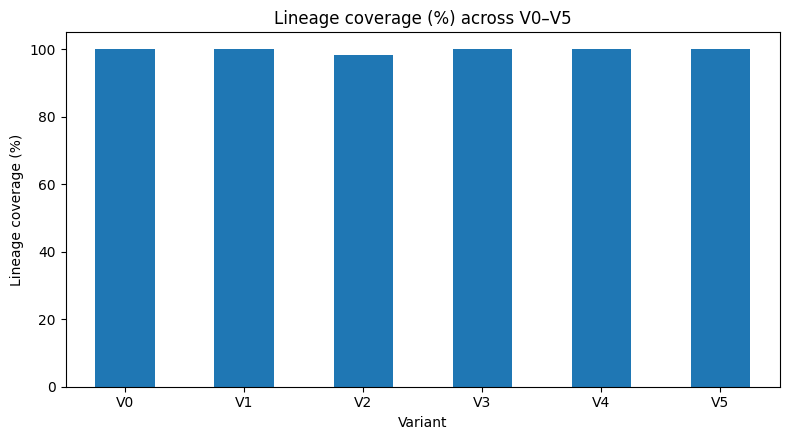

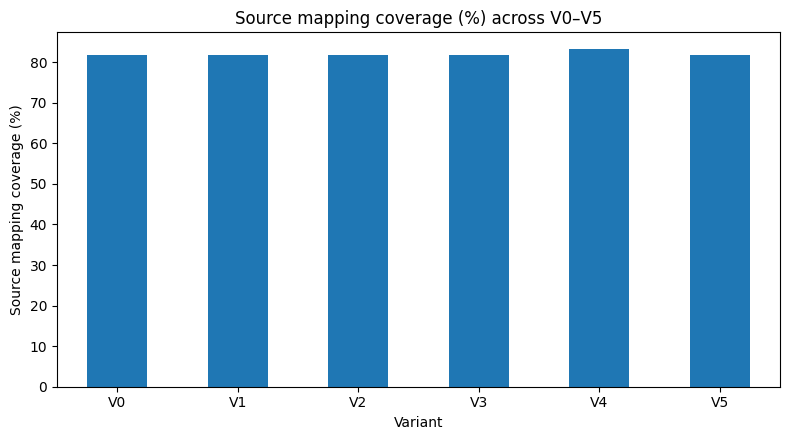

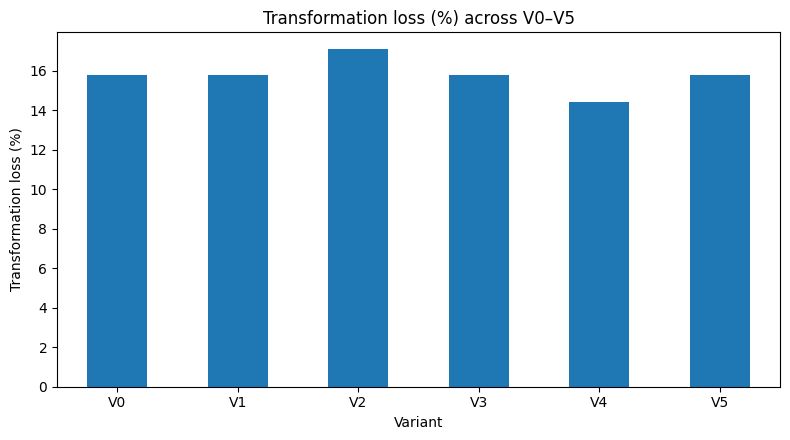

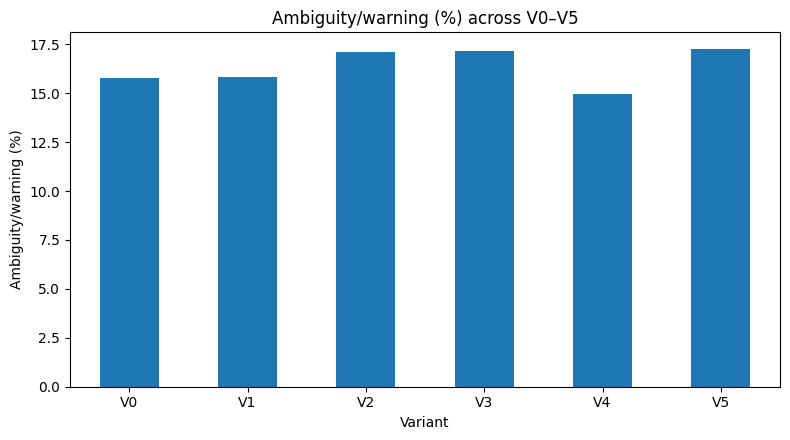

Saved primary-metric figures to: /content/drive/MyDrive/fhir_omop_colab/tfl_execution_v6/submission_freeze_v15/figures


In [14]:
import matplotlib.pyplot as plt

plot_df = MANUSCRIPT_PRIMARY_TABLE.set_index(
    "variant"
)

metric_names = [
    "Lineage coverage (%)",
    "Source mapping coverage (%)",
    "Transformation loss (%)",
    "Ambiguity/warning (%)",
]

for metric in metric_names:
    fig, ax = plt.subplots(
        figsize=(8, 4.5)
    )

    plot_df[metric].plot(
        kind="bar",
        ax=ax,
    )

    ax.set_xlabel("Variant")
    ax.set_ylabel(metric)
    ax.set_title(metric + " across V0–V5")
    ax.tick_params(
        axis="x",
        rotation=0,
    )

    fig.tight_layout()

    safe_name = (
        metric.lower()
        .replace(" ", "_")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
        .replace("%", "percent")
    )

    fig.savefig(
        V15_FIGURE_DIR
        / f"{safe_name}_v15.png",
        dpi=220,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

print(
    "Saved primary-metric figures to:",
    V15_FIGURE_DIR,
)

# Phase G

## Export final evidence package

In [15]:
for variant in VARIANTS:
    FINAL_AUDITS[variant].to_parquet(
        V15_AUDIT_DIR
        / f"{variant}_tfl_final_v15.parquet",
        index=False,
    )

PREINTEGRATION_METRICS.reset_index().to_csv(
    V15_TABLE_DIR
    / "preintegration_primary_metrics_v10_v11.csv",
    index=False,
)

FINAL_METRICS.reset_index().to_csv(
    V15_TABLE_DIR
    / "final_primary_metrics_v15.csv",
    index=False,
)

MANUSCRIPT_PRIMARY_TABLE.to_csv(
    V15_TABLE_DIR
    / "manuscript_primary_metric_table_v15.csv",
    index=False,
)

OLD_MEDICATION_WARNING_COUNTS.to_csv(
    V15_TABLE_DIR
    / "old_medication_warning_counts_v10.csv",
    index=False,
)

MEDICATION_MERGE_REPORT.to_csv(
    V15_TABLE_DIR
    / "hardened_medication_merge_report_v15.csv",
    index=False,
)

FINAL_EVENT_WARNING_COUNTS.to_csv(
    V15_TABLE_DIR
    / "final_event_warning_counts_v15.csv",
    index=False,
)

SOURCE_LEVEL_CONTROLLED_COUNTS.to_csv(
    V15_TABLE_DIR
    / "controlled_source_level_warning_counts_v15.csv",
    index=False,
)

REF_MICRO_SUMMARY.to_csv(
    V15_TABLE_DIR
    / "unresolved_reference_microtest_summary_v15.csv",
    index=False,
)

CALIBRATION.to_csv(
    V15_TABLE_DIR
    / "metric_calibration_gate_v15.csv",
    index=False,
)

INVARIANCE_GATE.to_csv(
    V15_TABLE_DIR
    / "metric_invariance_gate_v15.csv",
    index=False,
)

## Build hashes and environment manifest

In [16]:
def sha256_file(path, chunk_size=1024 * 1024):
    h = hashlib.sha256()

    with open(path, "rb") as handle:
        while True:
            chunk = handle.read(
                chunk_size
            )

            if not chunk:
                break

            h.update(chunk)

    return h.hexdigest()

manifest_rows = []

for root in [
    V15_AUDIT_DIR,
    V15_TABLE_DIR,
    V15_FIGURE_DIR,
]:
    for path in sorted(
        root.rglob("*")
    ):
        if not path.is_file():
            continue

        manifest_rows.append({
            "relative_path": str(
                path.relative_to(
                    V15_ROOT
                )
            ),
            "bytes": path.stat().st_size,
            "sha256": sha256_file(path),
        })

FILE_MANIFEST = pd.DataFrame(
    manifest_rows
)

FILE_MANIFEST.to_csv(
    V15_MANIFEST_DIR
    / "submission_file_manifest_v15.csv",
    index=False,
)

ENVIRONMENT = {
    "freeze_id": "FHIRy-pyOMOP-TFL-submission-freeze-v15",
    "created_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "python": sys.version,
    "platform": platform.platform(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "source_audit": "corrected v10 audit",
    "source_mapping_definition": "v11 unique-source-resource denominator",
    "medication_attribution": "hardened deterministic v14 rule",
    "unresolved_reference_test": "REF_MICRO_01",
    "tfl_schema_version": "1.0.0",
}

environment_path = (
    V15_MANIFEST_DIR
    / "environment_v15.json"
)

environment_path.write_text(
    json.dumps(
        ENVIRONMENT,
        indent=2,
    ),
    encoding="utf-8",
)

display(FILE_MANIFEST.head(20))
print(environment_path)

,relative_path,bytes,sha256
0,final_audits/V0_tfl_final_v15.parquet,12127297,4484aef3f5e449f43fd3fc261622f7e2c79f8589a62cb8...
1,final_audits/V1_tfl_final_v15.parquet,12126727,4ddb2656e241ea43099c0ee92afe262b56d2586a552236...
2,final_audits/V2_tfl_final_v15.parquet,12112479,141112ac657344c326b2fc0ca1c29ef5ad961ee0485f3b...
3,final_audits/V3_tfl_final_v15.parquet,12134591,42c242c11b3946c75503935f2185f0fee295b4926b81b7...
4,final_audits/V4_tfl_final_v15.parquet,11914825,cd23b61277d035ff72ee44b043d930695f7695486805a8...
5,final_audits/V5_tfl_final_v15.parquet,12134359,5318bad3cf6db79277ae5a90c602ddb7cb39322e49ece7...
6,tables/controlled_source_level_warning_counts_...,500,e7bf68b095e02bf09dc599f7407cb190c4e505196013d6...
7,tables/final_event_warning_counts_v15.csv,867,c9f6a8975a535374c5358b3e31f1d4040844d4e9123aab...
8,tables/final_primary_metrics_v15.csv,902,4cb956dda17033e4c3d4d0265c46c840a5ccea238848d1...
9,tables/hardened_medication_merge_report_v15.csv,174,984d89299f4ab4076f3d79959f60e29d97c0e6b6ba1dee...


/content/drive/MyDrive/fhir_omop_colab/tfl_execution_v6/submission_freeze_v15/manifests/environment_v15.json


## Final submission gate

In [17]:
FINAL_SUBMISSION_GATE = pd.DataFrame([
    {
        "gate": "v14_hardening_passed",
        "pass": bool(
            V14_GATE["pass"]
            .astype(bool)
            .all()
        ),
    },
    {
        "gate": "metric_definition_calibrated",
        "pass": bool(
            CALIBRATION["pass"]
            .all()
        ),
    },
    {
        "gate": "old_medication_fate_safe_to_replace",
        "pass": bool(
            (
                FATE_REVIEW[
                    "old_med_only_and_ambiguous"
                ]
                == 0
            ).all()
        ),
    },
    {
        "gate": "hardened_v4_medication_sources_1003",
        "pass": int(
            MEDICATION_MERGE_REPORT.loc[
                MEDICATION_MERGE_REPORT[
                    "variant"
                ].eq("V4"),
                "hardened_warning_source_resources",
            ].iloc[0]
        ) == 1003,
    },
    {
        "gate": "first_three_primary_metrics_invariant",
        "pass": bool(
            INVARIANCE_GATE["pass"]
            .all()
        ),
    },
    {
        "gate": "unresolved_reference_test_preserved",
        "pass": bool(
            (
                REF_MICRO_AUDIT[
                    "warning_code"
                ].astype(str)
                == "W_UNRESOLVED_REFERENCE"
            ).all()
            and (
                REF_MICRO_AUDIT[
                    "fidelity_status"
                ].astype(str)
                == "TRACEABILITY_LOSS"
            ).all()
        ),
    },
])

display(FINAL_SUBMISSION_GATE)

FINAL_SUBMISSION_GATE.to_csv(
    V15_TABLE_DIR
    / "final_submission_gate_v15.csv",
    index=False,
)

if not FINAL_SUBMISSION_GATE[
    "pass"
].all():
    raise RuntimeError(
        "v15 submission freeze gate failed."
    )

print(
    "PASS: v15 submission freeze gate complete."
)

,gate,pass
0,v14_hardening_passed,True
1,metric_definition_calibrated,True
2,old_medication_fate_safe_to_replace,True
3,hardened_v4_medication_sources_1003,True
4,first_three_primary_metrics_invariant,True
5,unresolved_reference_test_preserved,True


PASS: v15 submission freeze gate complete.


## Create one portable evidence archive

In [18]:
archive_path = (
    RUN_ROOT
    / "FHIRy_pyOMOP_TFL_submission_freeze_v15.zip"
)

if archive_path.exists():
    archive_path.unlink()

with zipfile.ZipFile(
    archive_path,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as zf:
    for path in sorted(
        V15_ROOT.rglob("*")
    ):
        if path.is_file():
            zf.write(
                path,
                arcname=str(
                    path.relative_to(
                        V15_ROOT
                    )
                ),
            )

archive_hash = sha256_file(
    archive_path
)

print("Evidence archive:", archive_path)
print("SHA256:", archive_hash)
print(
    "Size MB:",
    round(
        archive_path.stat().st_size
        / (1024 ** 2),
        2,
    ),
)

Evidence archive: /content/drive/MyDrive/fhir_omop_colab/tfl_execution_v6/FHIRy_pyOMOP_TFL_submission_freeze_v15.zip
SHA256: 3fd92db2f9ad2e77eeb5df768f58cb448d5fac298d58ce7a23b45c2d9eb08be0
Size MB: 49.8


# Phase H



- `manuscript_primary_metric_table_v15.csv` for the four final primary metrics;
- `controlled_source_level_warning_counts_v15.csv` for the controlled warning counts;
- `hardened_medication_merge_report_v15.csv` to distinguish **1,003 V4 source resources** flagged by the hardened medication rule from the number of audit-event rows inheriting that warning;
- `unresolved_reference_microtest_summary_v15.csv` for `REF_MICRO_01`.

The old broad medication-attribution result (V0 9,687 → V4 9,843) is retained only in the provenance table showing what was replaced. It should not be presented as the definitive medication-warning result.

If this notebook passes, P0.7 is complete. The remaining engineering step is P0.8: tag/release the exact repository state and archive the frozen code/data configuration.